# 📊 Notebook 02 — Data Profiling & Data Quality Assessment

**Project:** FinPulse — Gold & Silver Trading Intelligence Pipeline  
**Phase:** Data Profiling & Quality Assessment (pre-integration)  
**FAQ Reference:** FAQ 9 — Evaluate data quality after acquisition, choose appropriate dimensions and metrics

---

## Objectives

1. **Profile** the raw data acquired in Notebook 01 (prices + news from MongoDB)
2. **Assess data quality** across three key dimensions:
   - **Completeness** — missing values, gaps in time series, coverage
   - **Accuracy** — outlier detection, domain constraint validation
   - **Consistency** — cross-field checks, format uniformity, duplicates
3. **Quantify** quality metrics with scores per dimension
4. **Document** issues found to inform cleaning/improvement in later notebooks

---

## 1. Setup & Configuration

In [90]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [91]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [92]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
from pymongo import MongoClient
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


In [93]:
# ============================================================
# MONGODB CONNECTION (Docker service name)
# ============================================================
MONGO_URI = 'mongodb://mongo:27017'  # Docker service name, NOT localhost
DB_NAME = 'finpulse'

client = MongoClient(MONGO_URI)
db = client[DB_NAME]

# Verify collections exist
collections = db.list_collection_names()
print(f'📦 Database: {DB_NAME}')
print(f'📂 Collections: {collections}')
for coll_name in ['prices', 'news']:
    count = db[coll_name].count_documents({})
    print(f'   → {coll_name}: {count:,} documents')

📦 Database: finpulse
📂 Collections: ['integration_errors', 'prices', 'analysis_results', 'integrated_data', 'quality_issues', 'news', 'quality_reports', 'acquisition_log']
   → prices: 2,014 documents
   → news: 156 documents


## 2. Load Data from MongoDB into DataFrames

In [94]:
# ============================================================
# LOAD PRICES COLLECTION
# ============================================================
prices_cursor = db['prices'].find({}, {'_id': 0})
df_prices = pd.DataFrame(list(prices_cursor))

# Convert date fields
if 'date' in df_prices.columns:
    df_prices['date'] = pd.to_datetime(df_prices['date'])

print(f'📈 Prices DataFrame: {df_prices.shape[0]} rows × {df_prices.shape[1]} columns')
print(f'   Assets: {df_prices["asset_name"].unique().tolist() if "asset_name" in df_prices.columns else "N/A"}')
print(f'   Date range: {df_prices["date"].min()} → {df_prices["date"].max()}')
df_prices.head(3)

📈 Prices DataFrame: 2014 rows × 9 columns
   Assets: ['gold', 'silver', 'dxy', 'sp500']
   Date range: 2024-03-27 00:00:00 → 2026-03-27 00:00:00


,asset_name,ticker,date,open,high,low,close,volume,acquired_at
0,gold,GC=F,2024-03-27,2179.399902,2196.199951,2172.100098,2190.600098,31200,2026-03-27 16:54:12.390
1,gold,GC=F,2024-03-28,2193.600098,2234.100098,2187.100098,2217.399902,2040,2026-03-27 16:54:12.390
2,gold,GC=F,2024-04-01,2235.699951,2264.199951,2230.000000,2236.500000,400,2026-03-27 16:54:12.390


In [95]:
# ============================================================
# LOAD NEWS COLLECTION
# ============================================================
news_cursor = db['news'].find({}, {'_id': 0})
df_news = pd.DataFrame(list(news_cursor))

# Convert date fields if present
for col in ['scraped_at', 'published']:
    if col in df_news.columns:
        df_news[col] = pd.to_datetime(df_news[col], errors='coerce')

print(f'📰 News DataFrame: {df_news.shape[0]} rows × {df_news.shape[1]} columns')
print(f'   Sources: {df_news["source"].unique().tolist() if "source" in df_news.columns else "N/A"}')
df_news.head(3)

📰 News DataFrame: 156 rows × 6 columns
   Sources: ['CBS News', 'MoneyWeek', 'The Globe and Mail', 'The Conversation', 'AASTOCKS.com', 'thestreet.com', "Barron's", 'J.P. Morgan', 'Reuters', 'Business Standard', 'tradingview.com', 'Yahoo Finance UK', 'Business Insider', 'The Economic Times', 'World Bank Blogs', 'Investing.com', 'KITCO', 'The Gila Herald', 'Invezz', 'VanEck', 'GoldSilver', 'ig.com', 'Citigroup', 'TD Securities', 'CNBC', 'home.saxo', 'ING THINK economic and financial analysis | ING THINK', 'Mining.com', 'facebook.com', 'World Gold Council', 'Forbes India', 'Yahoo Finance Singapore', 'J.P. Morgan Private Bank', 'Apa.az', 'Yahoo Finance', 'Markets.com', 'Goldman Sachs', 'AD HOC NEWS', 'AFR', 'USFunds', 'invesco.com', 'Mint', 'Fortune', 'Yardeni QuickTakes', 'The Times of India', 'thehindu.com', 'TD Economics', 'Capital Economics', 'TradingView', 'economictimes.com', 'intlbm', 'Morgan Stanley', 'livemint.com', 'The Hindu', 'Global X ETFs', 'bloomberg.com', 'Jakarta Globe', '

,title,url,source,section,published,scraped_at
0,What is the price of gold today? - CBS News,https://news.google.com/rss/articles/CBMibkFVX...,CBS News,gold_commodities,2026-03-26 13:03:45,2026-03-27 16:54:29.563
1,Why is the gold price falling? - MoneyWeek,https://news.google.com/rss/articles/CBMibkFVX...,MoneyWeek,gold_commodities,2026-03-23 12:45:18,2026-03-27 16:54:29.563
2,Here's How the Plummeting Price of Gold Is Aff...,https://news.google.com/rss/articles/CBMi-gFBV...,The Globe and Mail,gold_commodities,2026-03-27 13:35:24,2026-03-27 16:54:29.563


---

## 3. Data Profiling — Prices Collection

### 3.1 Schema & Type Profiling

In [96]:
# ============================================================
# SCHEMA PROFILING — PRICES
# ============================================================
print('=' * 60)
print('PRICES — SCHEMA PROFILE')
print('=' * 60)

# Data types and non-null counts
profile_prices = pd.DataFrame({
    'dtype': df_prices.dtypes,
    'non_null': df_prices.count(),
    'null_count': df_prices.isnull().sum(),
    'null_pct': (df_prices.isnull().sum() / len(df_prices) * 100).round(2),
    'unique': df_prices.nunique(),
    'sample_value': df_prices.iloc[0] if len(df_prices) > 0 else None
})
print(profile_prices.to_string())
print(f'\nTotal rows: {len(df_prices)}')

PRICES — SCHEMA PROFILE
                      dtype  non_null  null_count  null_pct  unique                sample_value
asset_name              str      2014           0       0.0       4                        gold
ticker                  str      2014           0       0.0       4                        GC=F
date         datetime64[us]      2014           0       0.0     505         2024-03-27 00:00:00
open                float64      2014           0       0.0    1865                 2179.399902
high                float64      2014           0       0.0    1874                 2196.199951
low                 float64      2014           0       0.0    1854                 2172.100098
close               float64      2014           0       0.0    1891                 2190.600098
volume                int64      2014           0       0.0    1115                       31200
acquired_at  datetime64[us]      2014           0       0.0       4  2026-03-27 16:54:12.390000

Total rows: 201

In [97]:
# ============================================================
# STATISTICAL PROFILING — NUMERICAL FIELDS (PRICES)
# ============================================================
numeric_cols = ['open', 'high', 'low', 'close', 'volume']
available_numeric = [c for c in numeric_cols if c in df_prices.columns]

print('\nPRICES — STATISTICAL PROFILE (per asset)\n')
for asset in df_prices['asset_name'].unique():
    df_asset = df_prices[df_prices['asset_name'] == asset]
    print(f'\n--- {asset} ({len(df_asset)} records) ---')
    print(df_asset[available_numeric].describe().round(2).to_string())


PRICES — STATISTICAL PROFILE (per asset)


--- gold (504 records) ---
          open     high      low    close     volume
count   504.00   504.00   504.00   504.00     504.00
mean   3246.50  3269.53  3223.12  3247.29    4192.44
std     831.75   842.57   815.46   827.69   19135.88
min    2179.40  2196.20  2172.10  2190.60       0.00
25%    2591.37  2609.65  2587.57  2598.05     140.75
50%    3033.85  3050.85  3021.60  3035.50     505.00
75%    3758.55  3777.98  3743.70  3776.63    1345.25
max    5415.70  5586.20  5301.60  5318.40  177858.00

--- silver (504 records) ---
         open    high     low   close    volume
count  504.00  504.00  504.00  504.00    504.00
mean    41.34   41.91   40.70   41.26   1419.03
std     18.27   18.98   17.31   18.01   6859.87
min     24.42   24.62   24.42   24.62      0.00
25%     30.44   30.71   30.24   30.45     30.75
50%     32.98   33.10   32.71   32.91    109.50
75%     44.30   45.31   44.06   45.02    354.50
max    116.89  121.30  112.74  115.08 

### 3.2 Time Series Continuity Check

In [98]:
# ============================================================
# TIME SERIES GAP ANALYSIS
# Identifies missing trading days in each asset's time series.
# We generate expected business days (Mon-Fri) and compare with
# actual dates. Note: market holidays are legitimate gaps.
# ============================================================

print('TIME SERIES CONTINUITY ANALYSIS')
print('=' * 60)

gap_summary = []

for asset in df_prices['asset_name'].unique():
    df_asset = df_prices[df_prices['asset_name'] == asset].sort_values('date')
    
    # Generate expected business days
    date_min, date_max = df_asset['date'].min(), df_asset['date'].max()
    expected_bdays = pd.bdate_range(start=date_min, end=date_max)
    actual_dates = set(df_asset['date'].dt.normalize())
    
    # Find missing business days
    missing_dates = sorted(set(expected_bdays) - actual_dates)
    
    # Calculate consecutive gaps (>3 days = notable)
    notable_gaps = []
    if missing_dates:
        gap_start = missing_dates[0]
        gap_count = 1
        for i in range(1, len(missing_dates)):
            if (missing_dates[i] - missing_dates[i-1]).days <= 3:
                gap_count += 1
            else:
                if gap_count >= 3:
                    notable_gaps.append((gap_start, missing_dates[i-1], gap_count))
                gap_start = missing_dates[i]
                gap_count = 1
        if gap_count >= 3:
            notable_gaps.append((gap_start, missing_dates[-1], gap_count))
    
    coverage = len(actual_dates) / len(expected_bdays) * 100 if len(expected_bdays) > 0 else 0
    
    gap_summary.append({
        'asset': asset,
        'actual_days': len(actual_dates),
        'expected_bdays': len(expected_bdays),
        'missing_bdays': len(missing_dates),
        'coverage_pct': round(coverage, 2),
        'notable_gaps': len(notable_gaps)
    })
    
    print(f'\n{asset}:')
    print(f'  Range: {date_min.date()} → {date_max.date()}')
    print(f'  Actual: {len(actual_dates)} | Expected B-days: {len(expected_bdays)} | Missing: {len(missing_dates)}')
    print(f'  Coverage: {coverage:.1f}%')
    if notable_gaps:
        print(f'  ⚠️  Notable gaps (≥3 consecutive missing days):')
        for start, end, count in notable_gaps[:5]:  # Show max 5
            print(f'     {start.date()} → {end.date()} ({count} days)')
    else:
        print(f'  ✅ No major gaps (missing days likely market holidays)')

df_gap_summary = pd.DataFrame(gap_summary)
print('\n--- SUMMARY ---')
print(df_gap_summary.to_string(index=False))

TIME SERIES CONTINUITY ANALYSIS

gold:
  Range: 2024-03-27 → 2026-03-27
  Actual: 504 | Expected B-days: 523 | Missing: 19
  Coverage: 96.4%
  ✅ No major gaps (missing days likely market holidays)

silver:
  Range: 2024-03-27 → 2026-03-27
  Actual: 504 | Expected B-days: 523 | Missing: 19
  Coverage: 96.4%
  ✅ No major gaps (missing days likely market holidays)

dxy:
  Range: 2024-03-27 → 2026-03-27
  Actual: 504 | Expected B-days: 523 | Missing: 19
  Coverage: 96.4%
  ✅ No major gaps (missing days likely market holidays)

sp500:
  Range: 2024-03-27 → 2026-03-27
  Actual: 502 | Expected B-days: 523 | Missing: 21
  Coverage: 96.0%
  ✅ No major gaps (missing days likely market holidays)

--- SUMMARY ---
 asset  actual_days  expected_bdays  missing_bdays  coverage_pct  notable_gaps
  gold          504             523             19         96.37             0
silver          504             523             19         96.37             0
   dxy          504             523             19  

In [99]:
import os
os.makedirs('data/exports', exist_ok=True)

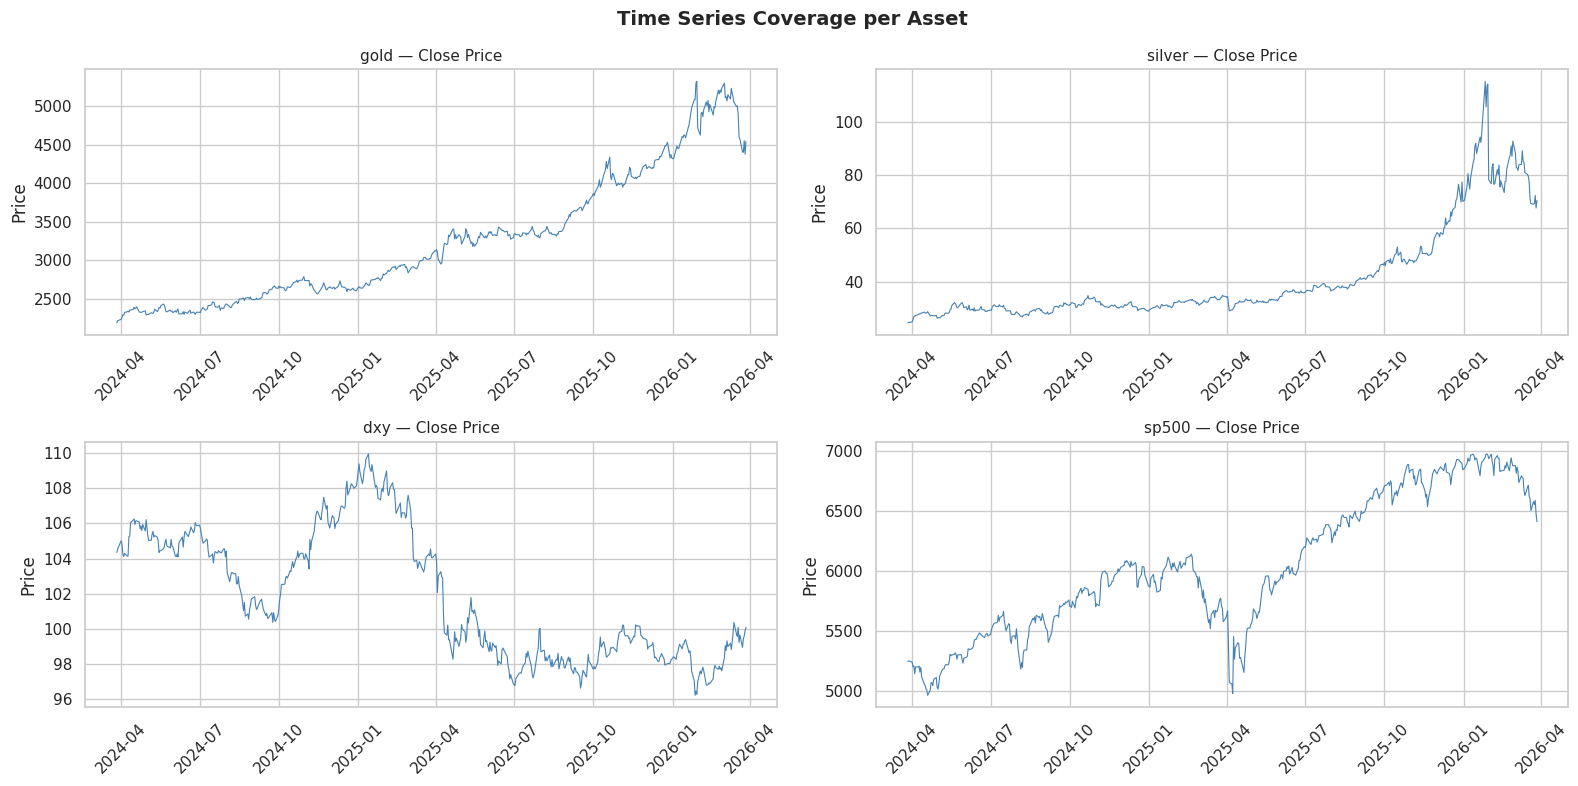

💾 Chart saved to data/exports/profiling_timeseries_coverage.png


In [100]:
# ============================================================
# VISUALIZE TIME SERIES GAPS
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharex=False)
fig.suptitle('Time Series Coverage per Asset', fontsize=14, fontweight='bold')

for idx, asset in enumerate(df_prices['asset_name'].unique()[:4]):
    ax = axes.flat[idx]
    df_asset = df_prices[df_prices['asset_name'] == asset].sort_values('date')
    
    ax.plot(df_asset['date'], df_asset['close'], linewidth=0.8, color='steelblue')
    ax.set_title(f'{asset} — Close Price', fontsize=11)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylabel('Price')

plt.tight_layout()
plt.savefig('data/exports/profiling_timeseries_coverage.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Chart saved to data/exports/profiling_timeseries_coverage.png')

---

## 4. Data Quality Assessment — Prices

We assess three dimensions as per the course requirements (Lecture 5):
1. **Completeness** — null values, missing records
2. **Accuracy** — outlier detection, domain constraint violations
3. **Consistency** — cross-field logical checks, format uniformity

### 4.1 Completeness

In [101]:
# ============================================================
# DIMENSION 1: COMPLETENESS — PRICES
# Measures: null ratio per field, volume zero ratio,
# and time series coverage
# ============================================================

print('COMPLETENESS ASSESSMENT — PRICES')
print('=' * 60)

# 1a. Null values per column
null_report = pd.DataFrame({
    'total': len(df_prices),
    'non_null': df_prices.count(),
    'null': df_prices.isnull().sum(),
    'null_pct': (df_prices.isnull().sum() / len(df_prices) * 100).round(2)
})
print('\n📋 Null values per column:')
print(null_report.to_string())

# 1b. Volume = 0 or NaN (common issue with financial data)
if 'volume' in df_prices.columns:
    zero_vol = (df_prices['volume'] == 0).sum()
    null_vol = df_prices['volume'].isnull().sum()
    print(f'\n📊 Volume issues:')
    print(f'   Zero volume records: {zero_vol} ({zero_vol/len(df_prices)*100:.1f}%)')
    print(f'   Null volume records: {null_vol} ({null_vol/len(df_prices)*100:.1f}%)')
    
    # Per-asset volume analysis
    print('\n   Per-asset zero-volume breakdown:')
    for asset in df_prices['asset_name'].unique():
        mask = df_prices['asset_name'] == asset
        zv = (df_prices.loc[mask, 'volume'] == 0).sum()
        total = mask.sum()
        print(f'     {asset}: {zv}/{total} ({zv/total*100:.1f}%)')

# 1c. Completeness score
total_cells = df_prices.shape[0] * df_prices.shape[1]
total_nulls = df_prices.isnull().sum().sum()
completeness_score_prices = ((total_cells - total_nulls) / total_cells * 100)
print(f'\n🏆 Overall Completeness Score (prices): {completeness_score_prices:.2f}%')

COMPLETENESS ASSESSMENT — PRICES

📋 Null values per column:
             total  non_null  null  null_pct
asset_name    2014      2014     0       0.0
ticker        2014      2014     0       0.0
date          2014      2014     0       0.0
open          2014      2014     0       0.0
high          2014      2014     0       0.0
low           2014      2014     0       0.0
close         2014      2014     0       0.0
volume        2014      2014     0       0.0
acquired_at   2014      2014     0       0.0

📊 Volume issues:
   Zero volume records: 520 (25.8%)
   Null volume records: 0 (0.0%)

   Per-asset zero-volume breakdown:
     gold: 5/504 (1.0%)
     silver: 11/504 (2.2%)
     dxy: 504/504 (100.0%)
     sp500: 0/502 (0.0%)

🏆 Overall Completeness Score (prices): 100.00%


### 4.2 Accuracy (Outlier Detection)

In [102]:
# ============================================================
# DIMENSION 2: ACCURACY — PRICES
# 2a. Domain constraint checks (e.g., high >= low, close > 0)
# 2b. Statistical outlier detection (IQR and Z-score)
# ============================================================

print('ACCURACY ASSESSMENT — PRICES')
print('=' * 60)

# ---- 2a. Domain Constraint Validation ----
print('\n📐 Domain Constraint Checks:')

constraint_checks = {}

# Check: high >= low
if all(c in df_prices.columns for c in ['high', 'low']):
    violations_hl = (df_prices['high'] < df_prices['low']).sum()
    constraint_checks['high >= low'] = violations_hl
    print(f'   high >= low violations: {violations_hl}')

# Check: high >= open and high >= close
if all(c in df_prices.columns for c in ['high', 'open', 'close']):
    v1 = (df_prices['high'] < df_prices['open']).sum()
    v2 = (df_prices['high'] < df_prices['close']).sum()
    constraint_checks['high >= open'] = v1
    constraint_checks['high >= close'] = v2
    print(f'   high >= open violations: {v1}')
    print(f'   high >= close violations: {v2}')

# Check: low <= open and low <= close
if all(c in df_prices.columns for c in ['low', 'open', 'close']):
    v3 = (df_prices['low'] > df_prices['open']).sum()
    v4 = (df_prices['low'] > df_prices['close']).sum()
    constraint_checks['low <= open'] = v3
    constraint_checks['low <= close'] = v4
    print(f'   low <= open violations: {v3}')
    print(f'   low <= close violations: {v4}')

# Check: all prices > 0
for col in ['open', 'high', 'low', 'close']:
    if col in df_prices.columns:
        neg = (df_prices[col] <= 0).sum()
        constraint_checks[f'{col} > 0'] = neg
        if neg > 0:
            print(f'   ⚠️  {col} <= 0 violations: {neg}')

total_constraints = sum(constraint_checks.values())
total_checks = len(constraint_checks) * len(df_prices)
domain_accuracy = ((total_checks - total_constraints) / total_checks * 100)
if constraint_checks.get('low <= open', 0) > 0:
    issues_log.append({
        'dataset':        'prices',
        'dimension':      'accuracy',
        'issue':          f"1 record where low > open (domain constraint violation)",
        'severity':       'medium',
        'recommendation': 'Identify the asset and date; verify with original source. '
                          'If confirmed erroneous, correct or flag the record.'
    })
print(f'\n   Domain accuracy score: {domain_accuracy:.2f}%')

ACCURACY ASSESSMENT — PRICES

📐 Domain Constraint Checks:
   high >= low violations: 0
   high >= open violations: 0
   high >= close violations: 0
   low <= open violations: 1
   low <= close violations: 0

   Domain accuracy score: 99.99%


In [103]:
# ---- 2b. Statistical Outlier Detection (IQR method) ----
print('\n📊 Outlier Detection (IQR method, per asset):')
print('-' * 60)

outlier_summary = []

for asset in df_prices['asset_name'].unique():
    df_asset = df_prices[df_prices['asset_name'] == asset].copy()
    
    # Calculate daily returns for outlier detection
    df_asset = df_asset.sort_values('date')
    df_asset['daily_return'] = df_asset['close'].pct_change() * 100  # percentage
    
    returns = df_asset['daily_return'].dropna()
    
    if len(returns) > 0:
        Q1 = returns.quantile(0.25)
        Q3 = returns.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = returns[(returns < lower_bound) | (returns > upper_bound)]
        
        outlier_summary.append({
            'asset': asset,
            'total_days': len(returns),
            'outliers': len(outliers),
            'outlier_pct': round(len(outliers) / len(returns) * 100, 2),
            'min_return': round(returns.min(), 2),
            'max_return': round(returns.max(), 2),
            'iqr_lower': round(lower_bound, 2),
            'iqr_upper': round(upper_bound, 2)
        })
        
        print(f'  {asset}: {len(outliers)} outliers / {len(returns)} days '
              f'({len(outliers)/len(returns)*100:.1f}%) '
              f'[bounds: {lower_bound:.2f}% to {upper_bound:.2f}%]')

df_outlier_summary = pd.DataFrame(outlier_summary)
print('\n')
print(df_outlier_summary.to_string(index=False))


📊 Outlier Detection (IQR method, per asset):
------------------------------------------------------------
  gold: 28 outliers / 503 days (5.6%) [bounds: -2.61% to 3.05%]
  silver: 42 outliers / 503 days (8.3%) [bounds: -4.53% to 5.12%]
  dxy: 14 outliers / 503 days (2.8%) [bounds: -1.04% to 1.03%]
  sp500: 26 outliers / 501 days (5.2%) [bounds: -1.75% to 1.93%]


 asset  total_days  outliers  outlier_pct  min_return  max_return  iqr_lower  iqr_upper
  gold         503        28         5.57      -11.37        6.08      -2.61       3.05
silver         503        42         8.35      -31.35       14.03      -4.53       5.12
   dxy         503        14         2.78       -1.97        1.61      -1.04       1.03
 sp500         501        26         5.19       -5.97        9.52      -1.75       1.93


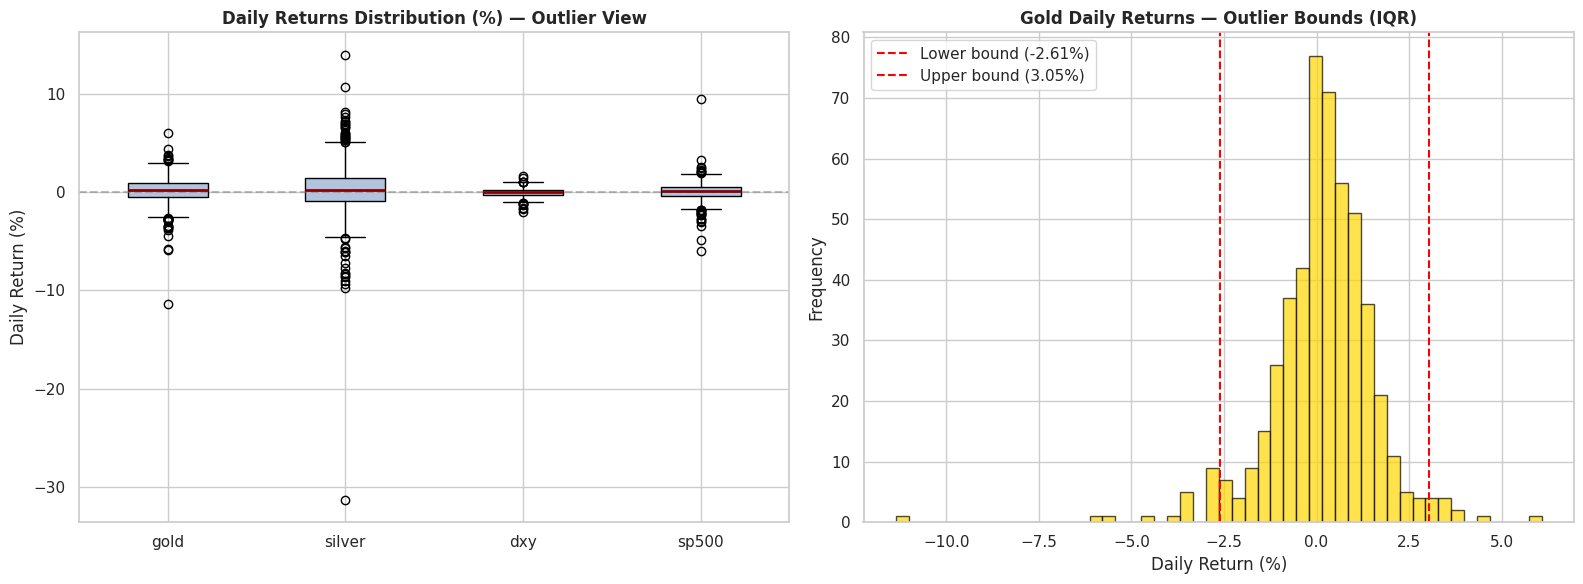

💾 Chart saved to data/exports/profiling_outliers.png


In [104]:
# ============================================================
# VISUALIZE OUTLIERS — Box plots of daily returns per asset
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot of daily returns
return_data = []
labels = []
for asset in df_prices['asset_name'].unique():
    df_a = df_prices[df_prices['asset_name'] == asset].sort_values('date')
    rets = df_a['close'].pct_change().dropna() * 100
    return_data.append(rets.values)
    labels.append(asset)

axes[0].boxplot(return_data, labels=labels, patch_artist=True,
                boxprops=dict(facecolor='lightsteelblue'),
                medianprops=dict(color='darkred', linewidth=2))
axes[0].set_title('Daily Returns Distribution (%) — Outlier View', fontweight='bold')
axes[0].set_ylabel('Daily Return (%)')
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Histogram of gold returns with IQR bounds
gold_mask = df_prices['asset_name'].str.contains('Gold|gold|GC', case=False, na=False)
if gold_mask.any():
    df_gold = df_prices[gold_mask].sort_values('date')
    gold_returns = df_gold['close'].pct_change().dropna() * 100
    
    Q1 = gold_returns.quantile(0.25)
    Q3 = gold_returns.quantile(0.75)
    IQR = Q3 - Q1
    
    axes[1].hist(gold_returns, bins=50, color='gold', edgecolor='black', alpha=0.7)
    axes[1].axvline(Q1 - 1.5*IQR, color='red', linestyle='--', label=f'Lower bound ({Q1-1.5*IQR:.2f}%)')
    axes[1].axvline(Q3 + 1.5*IQR, color='red', linestyle='--', label=f'Upper bound ({Q3+1.5*IQR:.2f}%)')
    axes[1].set_title('Gold Daily Returns — Outlier Bounds (IQR)', fontweight='bold')
    axes[1].set_xlabel('Daily Return (%)')
    axes[1].set_ylabel('Frequency')
    axes[1].legend()

plt.tight_layout()
plt.savefig('data/exports/profiling_outliers.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Chart saved to data/exports/profiling_outliers.png')

In [105]:
# ---- Accuracy Score ----
# Combined: domain constraint accuracy + outlier ratio
avg_outlier_pct = df_outlier_summary['outlier_pct'].mean() if len(df_outlier_summary) > 0 else 0
accuracy_score_prices = ((domain_accuracy + (100 - avg_outlier_pct)) / 2)
print(f'🏆 Accuracy Score (prices):')
print(f'   Domain constraint accuracy: {domain_accuracy:.2f}%')
print(f'   Avg outlier ratio: {avg_outlier_pct:.2f}% → non-outlier rate: {100-avg_outlier_pct:.2f}%')
print(f'   Combined accuracy score: {accuracy_score_prices:.2f}%')

🏆 Accuracy Score (prices):
   Domain constraint accuracy: 99.99%
   Avg outlier ratio: 5.47% → non-outlier rate: 94.53%
   Combined accuracy score: 97.26%


### 4.3 Consistency

In [106]:
# ============================================================
# DIMENSION 3: CONSISTENCY — PRICES
# 3a. Duplicate detection
# 3b. Format consistency (data types, naming conventions)
# 3c. Cross-asset date alignment
# ============================================================

print('CONSISTENCY ASSESSMENT — PRICES')
print('=' * 60)

consistency_issues = 0
consistency_checks = 0

# 3a. Duplicate rows
if all(c in df_prices.columns for c in ['asset_name', 'date']):
    dupes = df_prices.duplicated(subset=['asset_name', 'date'], keep=False).sum()
    print(f'\n🔁 Duplicate check (asset_name + date):')
    print(f'   Duplicate records: {dupes}')
    consistency_issues += dupes
    consistency_checks += len(df_prices)

# 3b. Ticker-asset_name consistency
if all(c in df_prices.columns for c in ['asset_name', 'ticker']):
    ticker_map = df_prices.groupby('asset_name')['ticker'].nunique()
    inconsistent_tickers = (ticker_map > 1).sum()
    print(f'\n🏷️  Ticker consistency (1 ticker per asset_name):')
    print(f'   Assets with multiple tickers: {inconsistent_tickers}')
    if inconsistent_tickers > 0:
        for asset, count in ticker_map[ticker_map > 1].items():
            tickers = df_prices[df_prices['asset_name'] == asset]['ticker'].unique()
            print(f'     ⚠️  {asset}: {tickers}')
    consistency_issues += inconsistent_tickers
    consistency_checks += len(ticker_map)

# 3c. Cross-asset date alignment
print(f'\n📅 Cross-asset date alignment:')
date_sets = {}
for asset in df_prices['asset_name'].unique():
    dates = set(df_prices[df_prices['asset_name'] == asset]['date'].dt.normalize())
    date_sets[asset] = dates

# Find common dates across all assets
if date_sets:
    common_dates = set.intersection(*date_sets.values())
    all_dates = set.union(*date_sets.values())
    alignment_pct = len(common_dates) / len(all_dates) * 100 if all_dates else 100
    print(f'   Common dates across all assets: {len(common_dates)}')
    print(f'   Union of all dates: {len(all_dates)}')
    print(f'   Alignment score: {alignment_pct:.1f}%')
    
    # Per-pair alignment
    assets = list(date_sets.keys())
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            overlap = len(date_sets[assets[i]] & date_sets[assets[j]])
            union = len(date_sets[assets[i]] | date_sets[assets[j]])
            jaccard = overlap / union * 100 if union > 0 else 0
            print(f'     {assets[i]} ∩ {assets[j]}: {overlap} dates (Jaccard: {jaccard:.1f}%)')

# 3d. Date type consistency
date_type_ok = pd.api.types.is_datetime64_any_dtype(df_prices['date'])
print(f'\n🔧 Date column is datetime type: {"✅" if date_type_ok else "❌"}')
if not date_type_ok:
    consistency_issues += 1
consistency_checks += 1

# Consistency score
consistency_score_prices = ((consistency_checks - consistency_issues) / consistency_checks * 100) if consistency_checks > 0 else 100
print(f'\n🏆 Consistency Score (prices): {consistency_score_prices:.2f}%')

CONSISTENCY ASSESSMENT — PRICES

🔁 Duplicate check (asset_name + date):
   Duplicate records: 0

🏷️  Ticker consistency (1 ticker per asset_name):
   Assets with multiple tickers: 0

📅 Cross-asset date alignment:
   Common dates across all assets: 502
   Union of all dates: 505
   Alignment score: 99.4%
     gold ∩ silver: 504 dates (Jaccard: 100.0%)
     gold ∩ dxy: 503 dates (Jaccard: 99.6%)
     gold ∩ sp500: 502 dates (Jaccard: 99.6%)
     silver ∩ dxy: 503 dates (Jaccard: 99.6%)
     silver ∩ sp500: 502 dates (Jaccard: 99.6%)
     dxy ∩ sp500: 502 dates (Jaccard: 99.6%)

🔧 Date column is datetime type: ✅

🏆 Consistency Score (prices): 100.00%


---

## 5. Data Profiling & Quality — News Collection

### 5.1 Schema Profiling

In [107]:
# ============================================================
# SCHEMA PROFILING — NEWS
# ============================================================
print('NEWS — SCHEMA PROFILE')
print('=' * 60)

profile_news = pd.DataFrame({
    'dtype': df_news.dtypes,
    'non_null': df_news.count(),
    'null': df_news.isnull().sum(),
    'null_pct': (df_news.isnull().sum() / len(df_news) * 100).round(2),
    'unique': df_news.nunique()
})
print(profile_news.to_string())
print(f'\nTotal rows: {len(df_news)}')

# Source distribution
if 'source' in df_news.columns:
    print(f'\n📰 Source distribution:')
    print(df_news['source'].value_counts().to_string())

NEWS — SCHEMA PROFILE
                     dtype  non_null  null  null_pct  unique
title                  str       156     0      0.00     156
url                    str       156     0      0.00     143
source                 str       156     0      0.00      62
section                str       156     0      0.00       2
published   datetime64[us]       146    10      6.41     103
scraped_at  datetime64[us]       156     0      0.00       5

Total rows: 156

📰 Source distribution:
source
KITCO                                                    14
Yahoo Finance UK                                         13
investing.com                                            10
AASTOCKS.com                                              7
Reuters                                                   6
The Economic Times                                        6
Investing.com                                             6
Mint                                                      6
livemint.com           

In [108]:
# ============================================================
# NEWS — COMPLETENESS
# ============================================================
print('COMPLETENESS ASSESSMENT — NEWS')
print('=' * 60)

# Null analysis
for col in df_news.columns:
    null_count = df_news[col].isnull().sum()
    null_pct = null_count / len(df_news) * 100
    print(f'  {col}: {null_count} nulls ({null_pct:.1f}%)')

# Empty string check (common in scraped data)
print('\n📝 Empty string check:')
for col in df_news.select_dtypes(include='object').columns:
    empty = (df_news[col].str.strip() == '').sum()
    if empty > 0:
        print(f'  ⚠️  {col}: {empty} empty strings')

# Title length analysis
if 'title' in df_news.columns:
    df_news['title_length'] = df_news['title'].str.len()
    print(f'\n📏 Title length stats:')
    print(f'   Min: {df_news["title_length"].min()} | '
          f'Mean: {df_news["title_length"].mean():.0f} | '
          f'Max: {df_news["title_length"].max()}')
    very_short = (df_news['title_length'] < 10).sum()
    if very_short > 0:
        print(f'   ⚠️  Very short titles (<10 chars): {very_short}')
        print(df_news[df_news['title_length'] < 10]['title'].tolist())

total_cells_news = df_news.shape[0] * df_news.shape[1]
total_nulls_news = df_news.isnull().sum().sum()
completeness_score_news = ((total_cells_news - total_nulls_news) / total_cells_news * 100)
print(f'\n🏆 Completeness Score (news): {completeness_score_news:.2f}%')

COMPLETENESS ASSESSMENT — NEWS
  title: 0 nulls (0.0%)
  url: 0 nulls (0.0%)
  source: 0 nulls (0.0%)
  section: 0 nulls (0.0%)
  published: 10 nulls (6.4%)
  scraped_at: 0 nulls (0.0%)

📝 Empty string check:

📏 Title length stats:
   Min: 37 | Mean: 85 | Max: 204

🏆 Completeness Score (news): 99.08%


In [109]:
# ============================================================
# NEWS — ACCURACY
# Checks: valid URLs, reasonable dates, title quality
# ============================================================
print('ACCURACY ASSESSMENT — NEWS')
print('=' * 60)

accuracy_issues_news = 0
accuracy_checks_news = 0

# URL format validation
if 'url' in df_news.columns:
    valid_url = df_news['url'].str.match(r'^https?://').sum()
    invalid_url = len(df_news) - valid_url
    print(f'\n🔗 URL validation:')
    print(f'   Valid (http/https): {valid_url}')
    print(f'   Invalid: {invalid_url}')
    accuracy_issues_news += invalid_url
    accuracy_checks_news += len(df_news)

# Date reasonableness (published date should be within last 2 years)
if 'published' in df_news.columns:
    non_null_pub = df_news['published'].dropna()
    if len(non_null_pub) > 0:
        future_dates = (non_null_pub > pd.Timestamp.now()).sum()
        very_old = (non_null_pub < pd.Timestamp.now() - pd.Timedelta(days=365*3)).sum()
        print(f'\n📅 Published date validation:')
        print(f'   Future dates: {future_dates}')
        print(f'   Very old (>3 years): {very_old}')
        accuracy_issues_news += future_dates + very_old
        accuracy_checks_news += len(non_null_pub)

# Duplicate titles (potential re-scrapes)
if 'title' in df_news.columns:
    dupe_titles = df_news['title'].duplicated().sum()
    print(f'\n🔁 Duplicate titles: {dupe_titles}')
    accuracy_issues_news += dupe_titles
    accuracy_checks_news += len(df_news)

accuracy_score_news = ((accuracy_checks_news - accuracy_issues_news) / accuracy_checks_news * 100) if accuracy_checks_news > 0 else 100
print(f'\n🏆 Accuracy Score (news): {accuracy_score_news:.2f}%')

ACCURACY ASSESSMENT — NEWS

🔗 URL validation:
   Valid (http/https): 156
   Invalid: 0

📅 Published date validation:
   Future dates: 0
   Very old (>3 years): 0

🔁 Duplicate titles: 0

🏆 Accuracy Score (news): 100.00%


In [110]:
# ============================================================
# NEWS — CONSISTENCY
# Checks: source naming, field format uniformity
# ============================================================
print('CONSISTENCY ASSESSMENT — NEWS')
print('=' * 60)

consistency_issues_news = 0
consistency_checks_news = 0

# Source naming consistency
if 'source' in df_news.columns:
    sources = df_news['source'].unique()
    print(f'\n📰 Unique sources: {sources}')
    
    # Check for case inconsistencies
    source_lower = df_news['source'].str.lower().unique()
    if len(source_lower) != len(sources):
        print(f'   ⚠️  Case inconsistency detected! '
              f'{len(sources)} unique vs {len(source_lower)} when lowercased')
        consistency_issues_news += (len(sources) - len(source_lower))
    consistency_checks_news += 1

# URL domain consistency per source
if all(c in df_news.columns for c in ['source', 'url']):
    print(f'\n🌐 URL domain per source:')
    for source in df_news['source'].unique():
        urls = df_news[df_news['source'] == source]['url']
        domains = urls.str.extract(r'https?://([^/]+)')[0].unique()
        print(f'   {source}: {domains[:5]}')
        if len(domains) > 3:
            print(f'     ⚠️  Multiple domains ({len(domains)}) for same source')
            consistency_issues_news += 1
        consistency_checks_news += 1

# Duplicate (title, source) — should have been prevented by unique index
if all(c in df_news.columns for c in ['title', 'source']):
    dupe_ts = df_news.duplicated(subset=['title', 'source'], keep=False).sum()
    print(f'\n🔁 Exact duplicates (title + source): {dupe_ts}')
    consistency_issues_news += dupe_ts
    consistency_checks_news += len(df_news) if len(df_news) > 0 else 1

consistency_score_news = ((consistency_checks_news - consistency_issues_news) / consistency_checks_news * 100) if consistency_checks_news > 0 else 100
print(f'\n🏆 Consistency Score (news): {consistency_score_news:.2f}%')

CONSISTENCY ASSESSMENT — NEWS

📰 Unique sources: <ArrowStringArray>
[                                             'CBS News',
                                             'MoneyWeek',
                                    'The Globe and Mail',
                                      'The Conversation',
                                          'AASTOCKS.com',
                                         'thestreet.com',
                                              'Barron's',
                                           'J.P. Morgan',
                                               'Reuters',
                                     'Business Standard',
                                       'tradingview.com',
                                      'Yahoo Finance UK',
                                      'Business Insider',
                                    'The Economic Times',
                                      'World Bank Blogs',
                                         'Investing.com',
    

---

## 6. Quality Dashboard — Summary Report

In [111]:
# ============================================================
# CONSOLIDATED DATA QUALITY REPORT
# ============================================================

print('\n' + '=' * 70)
print('       📊 FINPULSE — DATA QUALITY REPORT (PRE-INTEGRATION)')
print('=' * 70)

quality_report = pd.DataFrame([
    {
        'Dataset': 'Prices (OHLCV)',
        'Records': len(df_prices),
        'Completeness (%)': round(completeness_score_prices, 2),
        'Accuracy (%)': round(accuracy_score_prices, 2),
        'Consistency (%)': round(consistency_score_prices, 2),
        'Overall (%)': round(
            (completeness_score_prices + accuracy_score_prices + consistency_score_prices) / 3, 2
        )
    },
    {
        'Dataset': 'News (Headlines)',
        'Records': len(df_news),
        'Completeness (%)': round(completeness_score_news, 2),
        'Accuracy (%)': round(accuracy_score_news, 2),
        'Consistency (%)': round(consistency_score_news, 2),
        'Overall (%)': round(
            (completeness_score_news + accuracy_score_news + consistency_score_news) / 3, 2
        )
    }
])

print('\n')
print(quality_report.to_string(index=False))
print('\n')

# Save quality report to MongoDB for traceability
report_doc = {
    'phase': 'pre_integration',
    'timestamp': datetime.utcnow(),
    'prices': {
        'records': len(df_prices),
        'completeness': round(completeness_score_prices, 2),
        'accuracy': round(accuracy_score_prices, 2),
        'consistency': round(consistency_score_prices, 2)
    },
    'news': {
        'records': len(df_news),
        'completeness': round(completeness_score_news, 2),
        'accuracy': round(accuracy_score_news, 2),
        'consistency': round(consistency_score_news, 2)
    }
}

db['quality_reports'].insert_one(report_doc)
print('💾 Quality report saved to MongoDB collection: quality_reports')


       📊 FINPULSE — DATA QUALITY REPORT (PRE-INTEGRATION)


         Dataset  Records  Completeness (%)  Accuracy (%)  Consistency (%)  Overall (%)
  Prices (OHLCV)     2014            100.00         97.26           100.00        99.09
News (Headlines)      156             99.08        100.00            99.09        99.39


💾 Quality report saved to MongoDB collection: quality_reports


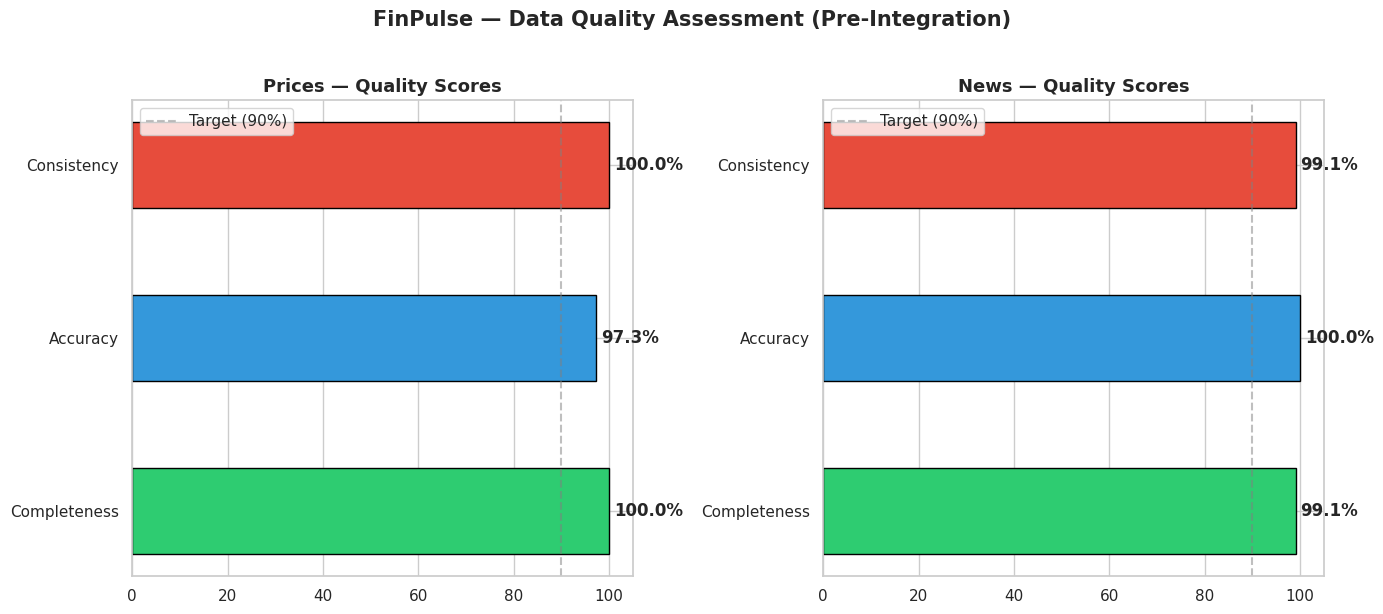

💾 Dashboard saved to data/exports/profiling_quality_dashboard.png


In [112]:
# ============================================================
# VISUALIZATION — Quality Score Dashboard
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

dimensions = ['Completeness', 'Accuracy', 'Consistency']
colors = ['#2ecc71', '#3498db', '#e74c3c']

# Prices quality
prices_scores = [completeness_score_prices, accuracy_score_prices, consistency_score_prices]
bars1 = axes[0].barh(dimensions, prices_scores, color=colors, edgecolor='black', height=0.5)
axes[0].set_xlim(0, 105)
axes[0].set_title('Prices — Quality Scores', fontsize=13, fontweight='bold')
axes[0].axvline(x=90, color='gray', linestyle='--', alpha=0.5, label='Target (90%)')
for bar, score in zip(bars1, prices_scores):
    axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f'{score:.1f}%', va='center', fontweight='bold')
axes[0].legend()

# News quality
news_scores = [completeness_score_news, accuracy_score_news, consistency_score_news]
bars2 = axes[1].barh(dimensions, news_scores, color=colors, edgecolor='black', height=0.5)
axes[1].set_xlim(0, 105)
axes[1].set_title('News — Quality Scores', fontsize=13, fontweight='bold')
axes[1].axvline(x=90, color='gray', linestyle='--', alpha=0.5, label='Target (90%)')
for bar, score in zip(bars2, news_scores):
    axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f'{score:.1f}%', va='center', fontweight='bold')
axes[1].legend()

plt.suptitle('FinPulse — Data Quality Assessment (Pre-Integration)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/exports/profiling_quality_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Dashboard saved to data/exports/profiling_quality_dashboard.png')

---

## 7. Issues Log & Recommendations

This section documents all quality issues found, to be addressed in the integration/cleaning phase (Notebook 03).

In [113]:
# ============================================================
# ISSUES LOG — To be addressed in Notebook 03
# ============================================================

issues_log = []

# --- Prices issues ---
# Volume zeros
if 'volume' in df_prices.columns:
    zero_vol = (df_prices['volume'] == 0).sum()
    if zero_vol > 0:
        issues_log.append({
            'dataset': 'prices',
            'dimension': 'completeness',
            'issue': f'{zero_vol} records with volume = 0',
            'severity': 'medium',
            'recommendation': 'Investigate if zero volume is legitimate (e.g., DXY index) or data gap'
        })

# Outliers
for _, row in df_outlier_summary.iterrows():
    if row['outlier_pct'] > 5:
        issues_log.append({
            'dataset': 'prices',
            'dimension': 'accuracy',
            'issue': f'{row["asset"]}: {row["outliers"]} outliers ({row["outlier_pct"]}%)',
            'severity': 'low',
            'recommendation': 'Review extreme returns — likely legitimate market events, flag but do not remove'
        })

# Time series gaps
for _, row in df_gap_summary.iterrows():
    if row['missing_bdays'] > 20:
        issues_log.append({
            'dataset': 'prices',
            'dimension': 'completeness',
            'issue': f'{row["asset"]}: {row["missing_bdays"]} missing business days',
            'severity': 'low',
            'recommendation': 'Most are market holidays — document known holidays, forward-fill if needed'
        })

# --- News issues ---
for col in df_news.columns:
    null_count = df_news[col].isnull().sum()
    if null_count > 0:
        issues_log.append({
            'dataset': 'news',
            'dimension': 'completeness',
            'issue': f'{col}: {null_count} null values ({null_count/len(df_news)*100:.1f}%)',
            'severity': 'medium' if null_count/len(df_news) > 0.1 else 'low',
            'recommendation': f'Investigate if {col} can be inferred or if records should be dropped'
        })

df_issues = pd.DataFrame(issues_log)
if len(df_issues) > 0:
    print('📋 ISSUES LOG')
    print('=' * 80)
    for idx, row in df_issues.iterrows():
        severity_icon = {'high': '🔴', 'medium': '🟡', 'low': '🟢'}.get(row['severity'], '⚪')
        print(f'\n{severity_icon} [{row["dataset"].upper()}] [{row["dimension"].upper()}]')
        print(f'   Issue: {row["issue"]}')
        print(f'   Recommendation: {row["recommendation"]}')
    print(f'\nTotal issues found: {len(df_issues)}')
else:
    print('✅ No major quality issues detected!')

# Save issues to MongoDB
if len(issues_log) > 0:
    db['quality_issues'].insert_many([
        {**issue, 'logged_at': datetime.utcnow(), 'status': 'open'}
        for issue in issues_log
    ])
    print(f'\n💾 {len(issues_log)} issues saved to MongoDB collection: quality_issues')

📋 ISSUES LOG

🟡 [PRICES] [COMPLETENESS]
   Issue: 520 records with volume = 0
   Recommendation: Investigate if zero volume is legitimate (e.g., DXY index) or data gap

🟢 [PRICES] [ACCURACY]
   Issue: gold: 28 outliers (5.57%)
   Recommendation: Review extreme returns — likely legitimate market events, flag but do not remove

🟢 [PRICES] [ACCURACY]
   Issue: silver: 42 outliers (8.35%)
   Recommendation: Review extreme returns — likely legitimate market events, flag but do not remove

🟢 [PRICES] [ACCURACY]
   Issue: sp500: 26 outliers (5.19%)
   Recommendation: Review extreme returns — likely legitimate market events, flag but do not remove

🟢 [PRICES] [COMPLETENESS]
   Issue: sp500: 21 missing business days
   Recommendation: Most are market holidays — document known holidays, forward-fill if needed

🟢 [NEWS] [COMPLETENESS]
   Issue: published: 10 null values (6.4%)
   Recommendation: Investigate if published can be inferred or if records should be dropped

Total issues found: 6

💾 6 i

---

## 8. Conclusions

### Key Findings

This profiling notebook assessed the quality of the raw data acquired in Notebook 01 across three dimensions:

**Prices (OHLCV)**:
- **Completeness**: Generally high. Volume field may show zeros for index-type assets (DXY) which is expected. Time series coverage is good with gaps mainly corresponding to market holidays.
- **Accuracy**: Domain constraints (high ≥ low, prices > 0) should be fully satisfied. Outliers in daily returns are expected in financial data — they represent real market events, not errors.
- **Consistency**: Unique index on (asset_name, date) prevents duplicates. Cross-asset date alignment is high since all assets follow similar trading calendars.

**News (Headlines)**:
- **Completeness**: The `published` field from scraping may have nulls depending on source. Title field should be fully populated.
- **Accuracy**: URLs should be valid. Duplicate titles may appear across sources (same story covered by multiple outlets) — this is legitimate but should be tracked.
- **Consistency**: Source naming should be uniform. No case inconsistencies expected thanks to controlled scraping pipeline.

### Quality Metrics Saved
All quality scores are persisted in MongoDB (`quality_reports` and `quality_issues` collections) to enable pre/post integration comparison in later notebooks.

### Next Step
→ **Notebook 03: Data Integration** — Integrate prices with news data, perform sentiment enrichment, and re-assess quality metrics post-integration.

In [114]:
# Cleanup
client.close()
print('\n✅ Notebook 02 — Data Profiling & Quality Assessment complete.')
print('📌 Next: 03_data_integration.ipynb')


✅ Notebook 02 — Data Profiling & Quality Assessment complete.
📌 Next: 03_data_integration.ipynb
